In [1]:
#Carga de bibliotecas
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Cropping2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


(144, 192, 3)

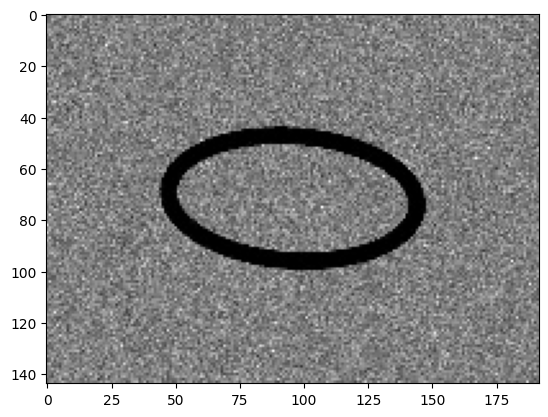

In [2]:
prueba=cv2.imread("datasets/phantomsSpeckle/train/Diastole/DiastoleRuido_010.jpg")
plt.imshow(prueba)
prueba.shape

In [3]:
def custom_loss(beta):
    def loss_function(y_true, y_pred):
        # Error cuadrático medio (MSE)
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        
        # Diferencia media entre etiquetas reales y predichas
        mean_diff = tf.reduce_mean(y_true - y_pred)
        
        # Pérdida total
        loss = mse + beta * tf.abs(mean_diff)
        return loss
    return loss_function

In [4]:
# Crear el modelo
model = Sequential()
model.add(Input(shape=(144, 192, 1)))
# Capas convolucionales
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
#Capa densa
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))
# Compilar el modelo
optimizer = Adam(learning_rate=1e-3)  
beta=0.2
model.compile(optimizer='adam', loss=custom_loss(beta), metrics=['precision'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 144, 192, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 72, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 96, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 13824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        13,825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,177 (164.75 KB)

 Trainable params: 42,177 (164.75 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
train_dir = 'datasets/phantomsSpeckle/train/'
validation_dir = 'datasets/phantomsSpeckle/validation/'

# Configuración de augmentación de datos
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Escala los píxeles entre 0 y 1
    shear_range=0.2,             # Cizallamiento aleatorio
    zoom_range=0.2,              # Zoom aleatorio
    horizontal_flip=True,        # Inversión horizontal aleatoria
    fill_mode='nearest'          # Método de relleno
)

validation_datagen = ImageDataGenerator(rescale=1./255)  # Normalización

# Generadores de datos de entrenamiento y validación
batch_size_train = 30  # Tamaño de lote ajustado

train_generator = train_datagen.flow_from_directory(
    train_dir,
    color_mode='grayscale',
    target_size=(144, 192),
    batch_size=batch_size_train,
    class_mode='binary'
)
batch_size_val = 10
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    color_mode='grayscale',
    target_size=(144, 192),
    batch_size=batch_size_val,
    class_mode='binary'
)

# Configuración del optimizador con tasa de aprendizaje baja
optimizer = Adam(learning_rate=1e-3)
beta=0.2
# Compilación del modelo
model.compile(optimizer=optimizer, loss=custom_loss(beta), metrics=['precision',AUC()])

# Entrenamiento del modelo
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)


Found 180 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


c:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 442ms/step - auc: 0.6581 - loss: 0.2614 - precision: 0.6861 - val_auc: 1.0000 - val_loss: 0.2524 - val_precision: 1.0000
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step - auc: 1.0000 - loss: 0.2198 - precision: 1.0000 - val_auc: 1.0000 - val_loss: 0.1150 - val_precision: 1.0000
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - auc: 1.0000 - loss: 0.1155 - precision: 1.0000 - val_auc: 1.0000 - val_loss: 0.0111 - val_precision: 1.0000
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 329ms/step - auc: 1.0000 - loss: 0.0120 - precision: 1.0000 - val_auc: 1.0000 - val_loss: 1.9278e-04 - val_precision: 1.0000
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - auc: 1.0000 - loss: 9.9425e-04 - precision: 1.0000 - val_auc: 1.0000 - val_loss: 1.1800e-05 - val_precision: 1.0000
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step - auc: 1.0000 - loss: 1.9440e-04 - precision: 1.0000 - val_auc: 1.0000 - val_loss: 3.7885e-06 - val_precision: 1.0000
Epoch 7/15
6/6 ━━━━━

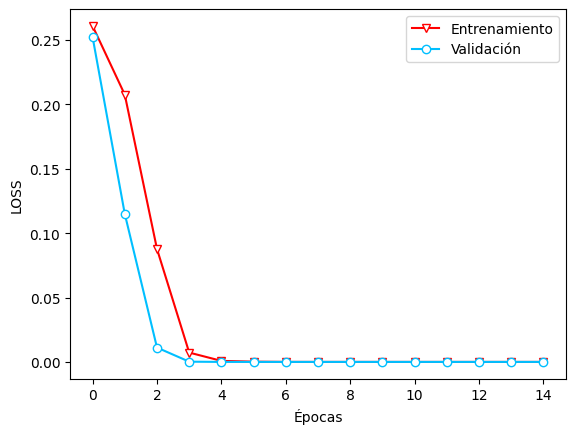

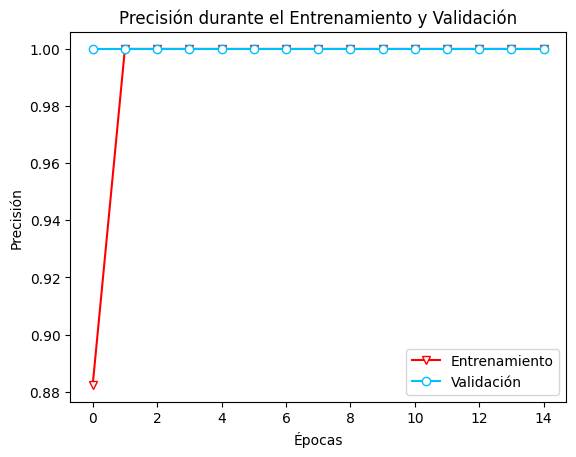

In [6]:
# Grafica la pérdida de entrenamiento y de validación
plt.plot(history.history['loss'], label='Entrenamiento',marker='v',markersize=6,color="red",markerfacecolor='white')
plt.plot(history.history['val_loss'], label='Validación',marker='o',markersize=6,color="deepskyblue",markerfacecolor='white')
plt.xlabel('Épocas')
plt.ylabel('LOSS')
plt.legend()
plt.savefig("LOSS_Speckle.png")
#plt.title('Pérdida durante el Entrenamiento y Validación')
plt.show()

# Grafica la precisión de entrenamiento y de validación
plt.plot(history.history['precision'],  label='Entrenamiento',marker='v',markersize=6,color="red",markerfacecolor='white')
plt.plot(history.history['val_precision'], label='Validación',marker='o',markersize=6,color="deepskyblue",markerfacecolor='white')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.title('Precisión durante el Entrenamiento y Validación')
plt.show()

In [7]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    color_mode='grayscale',
    target_size=(144, 192),
    class_mode='binary',
    shuffle=False
)

# Predecir todas las imágenes del directorio de entrenamiento
predictions=model.predict(train_generator)

# Convertir las predicciones a etiquetas binarias (opcional, dependiendo de tu problema)
train_predicted_classes = (predictions > 0.5).astype(int)  # Para problemas de clasificación binaria
train_true_classes = train_generator.classes

Found 180 images belonging to 2 classes.


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step


<Figure size 800x600 with 0 Axes>

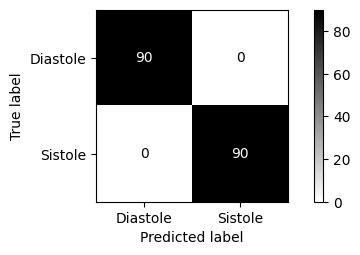

In [8]:
# Suponiendo que ya tienes las variables train_true_classes y train_predicted_classes definidas
train_cm = confusion_matrix(train_true_classes, train_predicted_classes)

# Crea el gráfico con un tamaño ajustado
plt.figure(figsize=(8, 6))  # Cambia el tamaño de la figura

# Mostrar la matriz de confusión
disp = ConfusionMatrixDisplay(train_cm, display_labels=train_generator.class_indices.keys())
disp.plot(cmap="binary", values_format='d')  # `values_format='d'` para mostrar números enteros

# Ajustar los márgenes si es necesario
plt.subplots_adjust(left=0.1, right=0.9, top=0.5, bottom=0.1)  # Ajusta según sea necesario

# Cambiar el tamaño de la fuente en las etiquetas
#plt.title("Matriz de Confusión - Entrenamiento", fontsize=14)  # Puedes ajustar el tamaño de la fuente aquí
plt.savefig("GraficaMatrizConfusionEntrenamientoSpeckle.png")

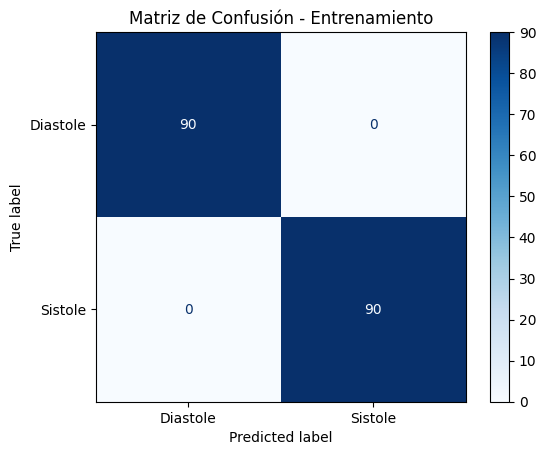

In [9]:
train_cm = confusion_matrix(train_true_classes, train_predicted_classes)
ConfusionMatrixDisplay(train_cm, display_labels=train_generator.class_indices.keys()).plot(cmap="Blues")
plt.title("Matriz de Confusión - Entrenamiento")
plt.show()

In [10]:
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    color_mode='grayscale',
    target_size=(144, 192),
    batch_size=batch_size_val,
    class_mode='binary',
    shuffle=False
)

# Predecir todas las imágenes del directorio de entrenamiento
predictions=model.predict(validation_generator)

# Convertir las predicciones a etiquetas binarias (opcional, dependiendo de tu problema)
validation_predicted_classes = (predictions > 0.5).astype(int)  # Para problemas de clasificación binaria
validation_true_classes = validation_generator.classes

Found 20 images belonging to 2 classes.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


c:\Users\alex2\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


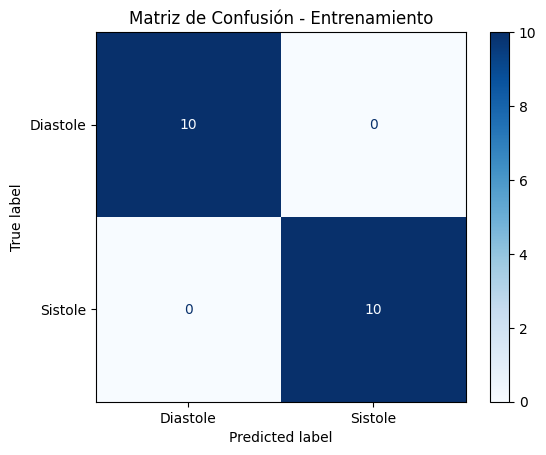

In [11]:
validation_cm = confusion_matrix(validation_true_classes, validation_predicted_classes)
ConfusionMatrixDisplay(validation_cm, display_labels=validation_generator.class_indices.keys()).plot(cmap="Blues")
plt.title("Matriz de Confusión - Entrenamiento")
plt.show()

<Figure size 800x600 with 0 Axes>

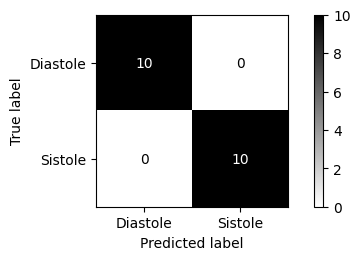

In [12]:
# Suponiendo que ya tienes las variables train_true_classes y train_predicted_classes definidas
validation_cm = confusion_matrix(validation_true_classes, validation_predicted_classes)

# Crea el gráfico con un tamaño ajustado
plt.figure(figsize=(8, 6))  # Cambia el tamaño de la figura

# Mostrar la matriz de confusión
disp = ConfusionMatrixDisplay(validation_cm, display_labels=validation_generator.class_indices.keys())
disp.plot(cmap="binary", values_format='d')  # `values_format='d'` para mostrar números enteros

# Ajustar los márgenes si es necesario
plt.subplots_adjust(left=0.1, right=0.9, top=0.5, bottom=0.1)  # Ajusta según sea necesario

# Cambiar el tamaño de la fuente en las etiquetas
#plt.title("Matriz de Confusión - Entrenamiento", fontsize=14)  # Puedes ajustar el tamaño de la fuente aquí
plt.savefig("GraficaMatrizConfusionTestSpckle.png")